In [2]:
!pip install holidays


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!pip install lightgbm


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import pandas as pd
import numpy as np
import glob
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Load Demand Data
demand_df = pd.read_csv('data/electricity/demand.csv', parse_dates=['datetime'])
demand_df.set_index('datetime', inplace=True)

# 2. Load and Aggregate Weather Data
weather_files = glob.glob("data/Weather/*.csv")
weather_dfs =[]

for file in weather_files:
    df = pd.read_csv(file, parse_dates=['datetime'])
    weather_dfs.append(df)

weather_raw = pd.concat(weather_dfs, ignore_index=True)

# Select only numerical columns for the regional average
# We drop 'wind_direction' (categorical string) to easily calculate the mean
num_weather_cols =['precipitation', 'temperature', 'dew_point_temperature', 'humidity', 'wind_speed', 'snowfall']

# Group by datetime and take the mean across all Kansai cities
weather_regional = weather_raw.groupby('datetime')[num_weather_cols].mean()

# 3. Merge Safely (One row per hour strictly)
data = demand_df.join(weather_regional, how='inner')

print(f"Data shape after correct merge: {data.shape}")

Data shape after correct merge: (26280, 7)


In [7]:
# Install holidays package if you don't have it: pip install holidays
import holidays

target_col = 'actual_performance(10000 kW)'

# --- A. Time & Calendar Features ---
data['hour'] = data.index.hour
data['dayofweek'] = data.index.dayofweek
data['month'] = data.index.month

# Cyclical Encoding for Time (Crucial for Neural Nets & helpful for Trees)
data['hour_sin'] = np.sin(2 * np.pi * data['hour'] / 23.0)
data['hour_cos'] = np.cos(2 * np.pi * data['hour'] / 23.0)
data['month_sin'] = np.sin(2 * np.pi * (data['month'] - 1) / 11.0)
data['month_cos'] = np.cos(2 * np.pi * (data['month'] - 1) / 11.0)

# Japanese Holidays Flag
jp_holidays = holidays.JP(years=[2021, 2022, 2023])
data['is_holiday'] = data.index.normalize().isin(jp_holidays).astype(int)
data['is_weekend'] = data['dayofweek'].isin([5, 6]).astype(int)

# --- B. Domain-Specific Weather Features ---
# Heating Degree Days (HDD) & Cooling Degree Days (CDD)
# Thresholds: Below 18C people heat, Above 24C people use AC
data['HDD'] = np.maximum(0, 18 - data['temperature'])
data['CDD'] = np.maximum(0, data['temperature'] - 24)

# --- C. SAFE Lag Features (Strictly >= 24 hours) ---
# We CANNOT use lag_1 or rolling_24h ending at the current hour!
data['lag_24'] = data[target_col].shift(24)   # Exact same hour yesterday
data['lag_48'] = data[target_col].shift(48)   # Exact same hour 2 days ago
data['lag_168'] = data[target_col].shift(168) # Exact same hour last week

# Safe rolling features (Rolling mean of the PAST 24 hours, calculated from yesterday)
data['rolling_mean_24h_lagged'] = data['lag_24'].rolling(window=24).mean()

# Drop NaNs generated by shifting 168 hours (1 week)
data.dropna(inplace=True)
data.to_csv('data/merged_dataset.csv')
data.head()

C:\Users\junjo\AppData\Local\Temp\ipykernel_17152\822896121.py:19: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  data['is_holiday'] = data.index.normalize().isin(jp_holidays).astype(int)


,actual_performance(10000 kW),precipitation,temperature,dew_point_temperature,humidity,wind_speed,snowfall,hour,dayofweek,month,...,month_sin,month_cos,is_holiday,is_weekend,HDD,CDD,lag_24,lag_48,lag_168,rolling_mean_24h_lagged
datetime,,,,,,,,,,,,,,,,,,,,,
2021-01-08 00:00:00,1857,0.142857,-1.557143,-8.542857,60.142857,4.242857,0.142857,0,4,1,...,0.0,1.0,0,0,19.557143,0.0,1608.0,1538.0,1571.0,1894.708333
2021-01-08 01:00:00,1785,0.071429,-1.757143,-8.728571,60.142857,4.100000,0.000000,1,4,1,...,0.0,1.0,0,0,19.757143,0.0,1560.0,1488.0,1492.0,1897.708333
2021-01-08 02:00:00,1772,0.000000,-1.757143,-8.457143,60.857143,3.785714,0.000000,2,4,1,...,0.0,1.0,0,0,19.757143,0.0,1571.0,1496.0,1453.0,1900.833333
2021-01-08 03:00:00,1758,0.000000,-1.685714,-8.257143,61.000000,4.428571,0.000000,3,4,1,...,0.0,1.0,0,0,19.685714,0.0,1566.0,1497.0,1412.0,1903.708333
2021-01-08 04:00:00,1730,0.000000,-2.100000,-8.400000,62.571429,4.557143,0.000000,4,4,1,...,0.0,1.0,0,0,20.100000,0.0,1544.0,1491.0,1358.0,1905.916667


In [8]:
# Split: Train on 2021-2022, Test on 2023
train = data.loc[:'2022-12-31 23:00:00'].copy()
test = data.loc['2023-01-01 00:00:00':].copy()

# Separate features and target
features = [col for col in data.columns if col != target_col]

X_train, y_train = train[features], train[target_col]
X_test, y_test = test[features], test[target_col]

print(f"Training rows: {len(X_train)}, Testing rows: {len(X_test)}")
X_train.head()

Training rows: 17352, Testing rows: 8760


,precipitation,temperature,dew_point_temperature,humidity,wind_speed,snowfall,hour,dayofweek,month,hour_sin,...,month_sin,month_cos,is_holiday,is_weekend,HDD,CDD,lag_24,lag_48,lag_168,rolling_mean_24h_lagged
datetime,,,,,,,,,,,,,,,,,,,,,
2021-01-08 00:00:00,0.142857,-1.557143,-8.542857,60.142857,4.242857,0.142857,0,4,1,0.000000,...,0.0,1.0,0,0,19.557143,0.0,1608.0,1538.0,1571.0,1894.708333
2021-01-08 01:00:00,0.071429,-1.757143,-8.728571,60.142857,4.100000,0.000000,1,4,1,0.269797,...,0.0,1.0,0,0,19.757143,0.0,1560.0,1488.0,1492.0,1897.708333
2021-01-08 02:00:00,0.000000,-1.757143,-8.457143,60.857143,3.785714,0.000000,2,4,1,0.519584,...,0.0,1.0,0,0,19.757143,0.0,1571.0,1496.0,1453.0,1900.833333
2021-01-08 03:00:00,0.000000,-1.685714,-8.257143,61.000000,4.428571,0.000000,3,4,1,0.730836,...,0.0,1.0,0,0,19.685714,0.0,1566.0,1497.0,1412.0,1903.708333
2021-01-08 04:00:00,0.000000,-2.100000,-8.400000,62.571429,4.557143,0.000000,4,4,1,0.887885,...,0.0,1.0,0,0,20.100000,0.0,1544.0,1491.0,1358.0,1905.916667


In [9]:
import numpy as np
import lightgbm as lgb
import pprint
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Define Time Series Cross-Validation
# We use 5 splits. The training set grows chronologically.
tscv = TimeSeriesSplit(n_splits=5)

# 2. Define the Hyperparameter Search Space
param_dist = {
    'n_estimators': [300, 500, 800],           # Number of boosting rounds
    'learning_rate':[0.01, 0.03, 0.05, 0.1],  # Step size
    'max_depth':[5, 7, 9, 12],                # Maximum tree depth
    'num_leaves':[31, 63, 127, 255],          # Number of leaves (controls complexity)
    'min_child_samples': [20, 50, 100],        # Minimum data per leaf (prevents overfitting)
    'colsample_bytree':[0.7, 0.8, 0.9, 1.0],  # Fraction of features used per tree
    'subsample':[0.7, 0.8, 0.9, 1.0]          # Fraction of data used per tree
}

# 3. Initialize the base model (Using alpha=0.5 for the Median/Expected forecast)
base_model = lgb.LGBMRegressor(objective='quantile', alpha=0.5, random_state=42, n_jobs=-1)

# 4. Set up Randomized Search
# We optimize for Negative Mean Absolute Error to directly push MAPE/MAE down
print("Starting Hyperparameter Tuning with TimeSeriesSplit...")
random_search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_dist,
    n_iter=20,                 # Number of random combinations to try (increase if you have time)
    scoring='neg_mean_absolute_error', 
    cv=tscv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Fit to the training data (2021-2022)
random_search.fit(X_train, y_train)


# 5. Extract the best model and train the upper/lower bounds using these parameters
best_params = random_search.best_params_

# Re-train models with the optimal parameters
model_q50_tuned = lgb.LGBMRegressor(objective='quantile', alpha=0.5, **best_params, random_state=42, n_jobs=-1)
model_q10_tuned = lgb.LGBMRegressor(objective='quantile', alpha=0.1, **best_params, random_state=42, n_jobs=-1)
model_q90_tuned = lgb.LGBMRegressor(objective='quantile', alpha=0.9, **best_params, random_state=42, n_jobs=-1)

model_q50_tuned.fit(X_train, y_train)
model_q10_tuned.fit(X_train, y_train)
model_q90_tuned.fit(X_train, y_train)

# 6. Predict on the Test Set (2023)
y_pred_tuned = model_q50_tuned.predict(X_test)

# Calculate Evaluation Metrics
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
mape_tuned = mape(y_test, y_pred_tuned)
r2_tuned = r2_score(y_test, y_pred_tuned)

Starting Hyperparameter Tuning with TimeSeriesSplit...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000920 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2763
[LightGBM] [Info] Number of data points in the train set: 17352, number of used features: 21
[LightGBM] [Info] Start training from score 1589.500000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

In [10]:
print(f"\nBest Hyperparameters")
pprint.pprint(random_search.best_params_)

# 2. See how much better the best score was compared to others
print(f"\nBest Cross-Validation MAE: {-random_search.best_score_:.2f}")

# 7. Display Final Results
print("FINAL TUNED MODEL PERFORMANCE (TEST SET: 2023)")

print(f"R²:     {r2_tuned:.4f}")
print(f"MAE:    {mae_tuned:.2f} (10,000 kW)")
print(f"RMSE:   {rmse_tuned:.2f} (10,000 kW)")
print(f"MAPE:   {mape_tuned:.2f}%")


Best Hyperparameters
{'colsample_bytree': 0.8,
 'learning_rate': 0.1,
 'max_depth': 12,
 'min_child_samples': 50,
 'n_estimators': 800,
 'num_leaves': 127,
 'subsample': 1.0}

Best Cross-Validation MAE: 63.19
FINAL TUNED MODEL PERFORMANCE (TEST SET: 2023)
R²:     0.9663
MAE:    41.53 (10,000 kW)
RMSE:   60.65 (10,000 kW)
MAPE:   2.59%


C:\Users\junjo\AppData\Local\Temp\ipykernel_17152\2014057453.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(15), palette='viridis')


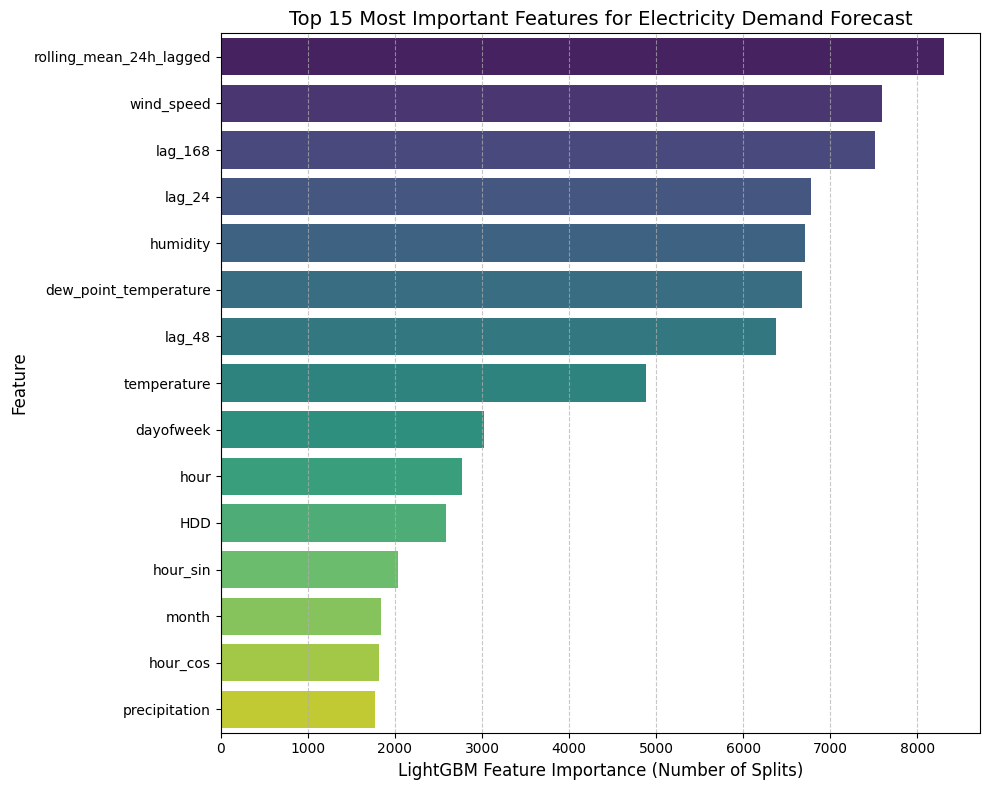

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the tuned median model
importances = model_q50_tuned.feature_importances_
feature_names = X_train.columns

# Create a DataFrame for visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot top 15 most important features
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(15), palette='viridis')
plt.title('Top 15 Most Important Features for Electricity Demand Forecast', fontsize=14)
plt.xlabel('LightGBM Feature Importance (Number of Splits)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

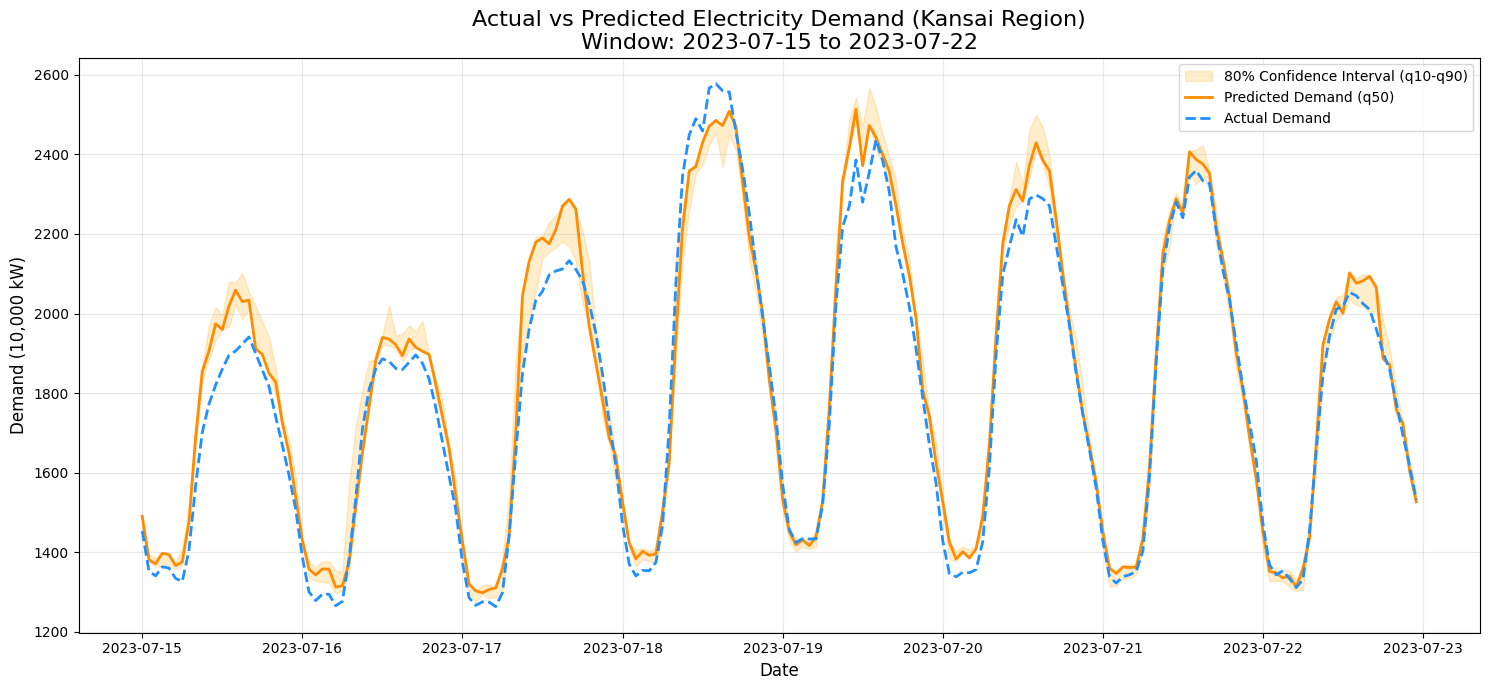

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Generate predictions for the entire test set
preds_50 = model_q50_tuned.predict(X_test)
preds_10 = model_q10_tuned.predict(X_test)
preds_90 = model_q90_tuned.predict(X_test)

# 2. Apply Monotonization (Ensuring Q90 is always >= Q50 >= Q10)
preds_10 = np.minimum(preds_10, preds_50)
preds_90 = np.maximum(preds_90, preds_50)

# 3. Create a results DataFrame for easy slicing
results_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted_Mid': preds_50,
    'Lower_Bound': preds_10,
    'Upper_Bound': preds_90
}, index=X_test.index)

# 4. SELECT A WINDOW (Let's look at one week in July - Peak Summer)
start_view = '2023-07-15'
end_view = '2023-07-22'
plot_data = results_df.loc[start_view:end_view]

# 5. CREATE THE PLOT
plt.figure(figsize=(15, 7))

# Plot the 80% Confidence Interval (Shaded Area)
plt.fill_between(plot_data.index, 
                 plot_data['Lower_Bound'], 
                 plot_data['Upper_Bound'], 
                 color='orange', alpha=0.2, label='80% Confidence Interval (q10-q90)')

# Plot Predicted Median
plt.plot(plot_data.index, plot_data['Predicted_Mid'], 
         color='darkorange', linewidth=2, label='Predicted Demand (q50)')

# Plot Actual Demand
plt.plot(plot_data.index, plot_data['Actual'], 
         color='dodgerblue', linewidth=2, linestyle='--', label='Actual Demand')

# Formatting
plt.title(f'Actual vs Predicted Electricity Demand (Kansai Region)\nWindow: {start_view} to {end_view}', fontsize=16)
plt.ylabel('Demand (10,000 kW)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

In [13]:
import joblib
import json
import os

# 1. Create a dedicated directory for our application assets
os.makedirs('app_assets', exist_ok=True)

# 2. Export the three trained LightGBM models
# joblib is the industry standard for saving tree-based models
joblib.dump(model_q10_tuned, 'app_assets/lgbm_q10.pkl')
joblib.dump(model_q50_tuned, 'app_assets/lgbm_q50.pkl')
joblib.dump(model_q90_tuned, 'app_assets/lgbm_q90.pkl')
print(" Models saved successfully.")

# 3. Export the exact feature list
# This guarantees our app sends columns to the model in the EXACT same order
features_list = list(X_train.columns)
with open('app_assets/model_features.json', 'w') as f:
    json.dump(features_list, f)
print(" Feature schema saved successfully.")

# 4. Export the Test Dataset (2023 Data)
# This will act as our "Live Database". The app will query this file 
# to get the "weather forecast" and "past lags" for whatever day the user selects.
test.to_csv('app_assets/app_database.csv')
print(" App database saved successfully.")


 Models saved successfully.
 Feature schema saved successfully.
 App database saved successfully.


In [14]:
import shap

model_q50_tuned = joblib.load('app_assets/lgbm_q50.pkl')
# TreeExplainer is specifically optimized for LightGBM
explainer = shap.TreeExplainer(model_q50_tuned)
joblib.dump(explainer, 'app_assets/shap_explainer.pkl')

print("SHAP Explainer exported successfully.")

SHAP Explainer exported successfully.
